# 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, json
import datetime
!pip install nltk


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [209]:
import sqlite3
conn=sqlite3.connect('product_launch.db')
df=pd.read_sql("SELECT * FROM products WHERE month BETWEEN '2024-01-01' AND '2025-12-01'",conn)

In [4]:
df.columns

Index(['asin', 'month', 'title', 'cat', 'raw_data', 'buybox', 'rating'], dtype='str')

Text(0, 0.5, 'launches')

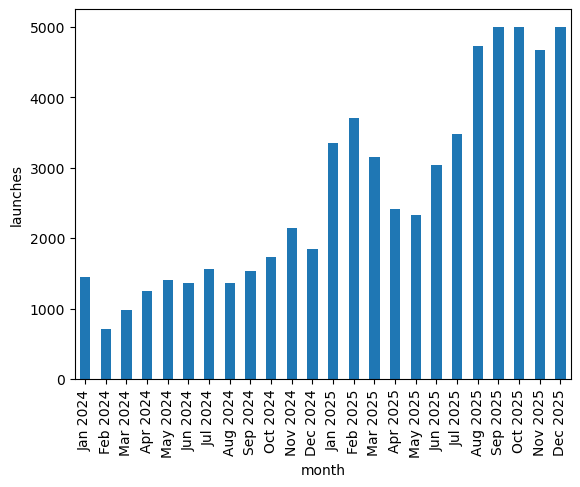

In [5]:
import datetime as datetime
df['month']=pd.to_datetime(df['month'])
monthly_counts=df['month'].value_counts().sort_index()
monthly_counts.index = monthly_counts.index.strftime('%b %Y')
ax=monthly_counts.plot(kind='bar')
plt.ylabel('launches')

In [6]:
df.shape

(63209, 7)

In [7]:
def absorbed_before_signal(raw):
    data = json.loads(raw)
    list_time = data.get('listedSince')
    if not list_time:
        return True
    history = data.get('parentAsinHistory') or []
    times = [int(t) for t in history[0::2]]
    asins = history[1::2]
    six_month_mins = list_time + 180 * 24 * 60
    for t, a in zip(times, asins):
        if t <= six_month_mins and a and a != '-1':
            return True
    return False

df['absorbed_early'] = df['raw_data'].map(absorbed_before_signal)
print(f"{df['absorbed_early'].mean()*100:.1f}% absorbed within 6 months")


47.9% absorbed within 6 months


In [8]:
# df=df[~df['absorbed_early']]
# df.head()

In [ ]:
df['brand_store_name']=df['raw_data'].map(lambda x: json.loads(x).get('brandStoreName',None))
df['target_audience_keyword']=df['raw_data'].map(lambda x: json.loads(x).get('targetAudienceKeyword',None))
df['material']=df['raw_data'].map(lambda x: json.loads(x).get('material',None))
df['description']=df['raw_data'].map(lambda x: json.loads(x).get('description',None))
df['competitive_price_threshold']=df['raw_data'].map(lambda x: json.loads(x).get('competitivePriceThreshold',None))
df['return_rate']=df['raw_data'].map(lambda x: json.loads(x).get('returnRate',None))
df['parent_asin']=df['raw_data'].map(lambda x: json.loads(x).get('parentAsinHistory',None))
df['listed_price']=df['raw_data'].map(lambda x: (json.loads(x).get('csv') or [None])[4])
df['price'] = df['listed_price'].map(lambda x: None if x is None else (None if x[1] is None else float(x[1]/100)))



In [ ]:
# # export title out for embedding
# df['title'].to_csv('title_total_new.csv',index=False)


In [ ]:
# add embeddings as features
embeddings=np.load('title_embedding_all.npy')
# need string to columns names
em_cols=[f'emb_{i}' for i in range(384)]
df_embedding=pd.DataFrame(embeddings,index=df.index,columns=em_cols)
df=df.join(df_embedding)

In [ ]:
# assign niche
from sklearn.cluster import KMeans
km=KMeans()

In [10]:
def was_absorbed(raw):
    history = json.loads(raw).get('parentAsinHistory') or []
    asins = history[1::2]  # odd indices are the parent ASIN values
    return any(a and a != '-1' for a in asins)

df['absorbed'] = df['raw_data'].map(was_absorbed)
print(f"{df['absorbed'].mean()*100:.1f}% of ASINs were absorbed into a variation family")
df_clean = df[~df['absorbed']]


100.0% of ASINs were absorbed into a variation family


In [11]:
df['title']=df['raw_data'].map(lambda x:json.loads(x).get('title',None))
# df['seller']=df['buybox'].map(lambda x: (json.loads(x).get('buyBoxSellerIdHistory') or [None])[-1])
# useless df['offer_successful']=df['raw_data'].map(lambda x: json.loads(x).get('offersSuccessful',None))


(-22046.600000000002, 637130.6)

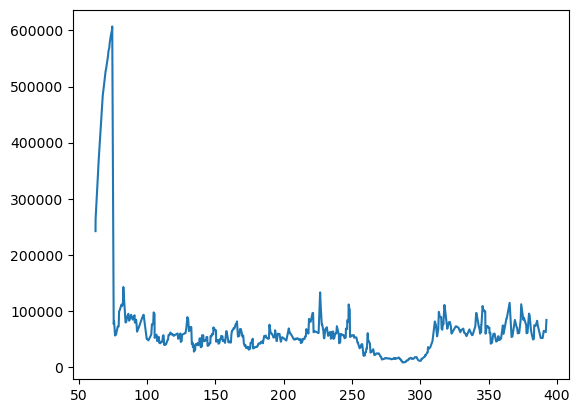

In [12]:
NUM=100
root_cat=json.loads(df['raw_data'].iloc[NUM])['rootCategory']
list_time=times=json.loads(df['raw_data'].iloc[NUM])['listedSince']
times=(json.loads(df['raw_data'].iloc[NUM])['salesRanks'].get(str(root_cat)) or [None])[0::2]
days=[(t-list_time)/60/24 for t in times]
rank=json.loads(df['raw_data'].iloc[NUM])['salesRanks'][str(root_cat)][1::2]
plt.plot(days,rank)
plt.ylim()

**We originally collected data from 2024-2025, however, upon investigating, we found that the year 2025 has significally higher launches than 2024. This makes sense because Keepa (where we collect data from) get rid of Asins that are expired. In a way, what left of 2024 is potential biased on being successful. We will keep this in mind.**

# 2. Target Variable: success or failure

**What is the definition of success? Salnikova et labeld successful food products as they are still selling on the manufacture's website 2 years post introduction. In the process of labeling whether a Crunchbase company is successful or no, Żbikowski etc chose completing series B as a milestone. Sharma etc uses product rating >=4/5 as the creteria to label a successful crowdfunded project. We initially considered monthly sales and review counts**

**update: upon talking with keepa team, we realized that reviewCount is collected if it is a child asin of some other asin and it will stop collecting if it get disassociated with parent asin. This lead us to miss a lot of data.**

**We further investigated using sales rank as a label. It is provided in csv field and as time series data. One note we observed is that one Asin might belong to one root categories and many subcategories, the sales rank data were provide respectively. One must be careful when extract sales rank to make sure rootCat is used as the key. Since it is a time series data, we decide to take sales rank @month 3-4 (day 60-70 30 day avg) and sales rank @month 6-7 (day 180-210 30 day avg) as signal.**

In [13]:
from typing import List

def convert_history_to_dict(original_list,list_time):
    """
    a helper function used in extraction().
    orignal_list: List[int] [time,count,time,count,..] 
    list_time: int
    return a dictionary {days:count,...}
    """
    if original_list !=None:
        times=original_list[0::2]
        days=[int((t-list_time)/60/24) for t in times] # format is mins from keepa_epoch (2011,1,1), convert mins to days
        counts=original_list[1::2]
        time_series_data =dict(zip(days,counts))
    else:
        time_series_data =None
    return time_series_data
def sales_rank_at_months(original_list,starting_days,ending_days,list_time):
    """
    a helper function used in extraction().
    from a dictionary (time: sale rank) get average sales rank for a time range
    """
    if original_list== None:
        return None
    
    starting_mins=starting_days*24*60+list_time # convert days to mins and take into account post_launch
    ending_mins=ending_days*24*60+list_time # convert days to mins and take into account post_launch

    times=original_list[0::2]
    counts=original_list[1::2]

    sum_rank=[]

    for i,k in enumerate(times):
        if counts[i] and counts[i] != -1:
            if k>=starting_mins and k<= ending_mins:
                sum_rank.append(counts[i])

    return sum(sum_rank)/len(sum_rank) if len(sum_rank)!=0 else None

def extraction(row): 
    """
    from one asin's feature_dictionary(e.g. df['raw_data].iloc[0]) extract monthlysold and review info
    return a Series
    """
    feature_dictionary=json.loads(row) # convert each df['raw_dat'] to a dictionary 
    list_time=feature_dictionary.get('listedSince',None)
    # extract monthly_sold and review history: list[time,count,time,count,..]
    time_n_monthly_sold=feature_dictionary.get('monthlySoldHistory',None)
    time_n_review_count=feature_dictionary.get('reviews',{}).get('reviewCount',None) # return a list of [time,count,time,count..]
    
    # extract sales rank
    root_cat=feature_dictionary.get('rootCategory') 
    time_n_sales_rank=(feature_dictionary.get('salesRanks') or {}).get(str(root_cat),None)

    # convert the list to a dicionary
    ms_history=convert_history_to_dict(time_n_monthly_sold,list_time)
    review_history=convert_history_to_dict(time_n_review_count,list_time)
    sales_rank_history=convert_history_to_dict(time_n_sales_rank,list_time)
    # process review
    most_recent_review_time=max(review_history.keys()) if review_history else None
    most_recent_review=review_history[most_recent_review_time] if review_history else None

    if review_history:
        review_na_count=sum([1 for v in review_history.values() if v==-1])  
    else:
        review_na_count=None,
    # process sales rank
    sales_rank_mean_3_month=sales_rank_at_months(time_n_sales_rank,90,120,list_time)
    sales_rank_mean_6_month=sales_rank_at_months(time_n_sales_rank,180,210,list_time)


    return pd.Series({
       'ms_history':ms_history, # will return None if empty
       'ms_is_empty':ms_history is None,
       'ms_na_count': sum([1 for v in ms_history.values() if v==-1]) if ms_history else None,
       'ms_total_time_points':len(ms_history) if ms_history else None,

       'review_history':review_history,
        'review_is_empty':review_history is None,
       'most_recent_review_time':most_recent_review_time,
       'most_recent_review':most_recent_review,
       'review_na_count':review_na_count,
       'review_total_time_points':len(review_history) if review_history else None,

       'sales_rank_history':sales_rank_history,
       'sale_rank_is_empty':sales_rank_history is None,
       'sales_rank_mean_3_month':sales_rank_mean_3_month,
       'sales_rank_mean_6_month':sales_rank_mean_6_month
   })
# every row will be extracted and pd Series will be returned per row
# series's index will become column when joined with df
df_update=df.join(df['raw_data'].apply(lambda x:extraction(x)))


**We noticed a lot of missing data. We started to investiage what percent of Asins don't have sales data or review data available?**

In [14]:
empty_sale_percent=df_update['ms_is_empty'].sum()/df_update.shape[0]
empty_review_percent=df_update['review_is_empty'].sum()/df_update.shape[0]
print(f"{empty_sale_percent*100:.2f}% Asin don't show sale history.")
print(f"{empty_review_percent*100:.2f}% Asin don't show review history.")

89.01% Asin don't show sale history.
0.00% Asin don't show review history.


In [15]:

na_sales_percent=df_update['ms_na_count'].fillna(0).sum()/df_update['ms_total_time_points'].fillna(0).sum()
na_review_percent=df_update['review_na_count'].sum()/df_update['review_total_time_points'].sum()
print(f"{na_sales_percent*100:.2f}% sales data show -1.")
print(f"{na_review_percent*100:.2f}% review data show -1.")

13.01% sales data show -1.
0.00% review data show -1.


In [16]:
df_new=df_update[df['month']<pd.to_datetime('2025-10-01')]
empty_sale_rank=df_update['sale_rank_is_empty'].sum()/df_update.shape[0]
empty_3_month_sales_rank=df_new['sales_rank_mean_3_month'].isnull().sum()/df_new.shape[0]
empty_6_month_sales_rank=df_new['sales_rank_mean_6_month'].isnull().sum()/df_new.shape[0]

print(f"{empty_sale_rank*100:.2f}% Asin don't show sales rank.")
print(f"{empty_3_month_sales_rank*100:.2f}% Asin don't show 3-month sales rank from Jan 2024 to Sep 2025.")
print(f"{empty_6_month_sales_rank*100:.2f}% Asin don't show 6-month sales rank from Jan 2024 to Sep 2025.")

both_null = (df_new['sales_rank_mean_3_month'].isnull() & df_new['sales_rank_mean_6_month'].isnull()).sum() / df_new.shape[0]
print(f"{both_null*100:.2f}% ASINs missing both")


8.69% Asin don't show sales rank.
29.86% Asin don't show 3-month sales rank from Jan 2024 to Sep 2025.
20.34% Asin don't show 6-month sales rank from Jan 2024 to Sep 2025.
19.61% ASINs missing both


**Do we use reviews or sales rank?**

In [17]:
# update df to exclude Oct 2025 to now
df_new=df_update[df['month']<pd.to_datetime('2025-10-01')]

has_rank_6_month = df_new['sales_rank_mean_6_month'].notnull()
has_review_6_month = df_new['most_recent_review_time'] >= 180
print("6_month_data_availability")

print(f"has rank: {(has_rank_6_month).mean()*100:.1f}%")
print(f"has review: {(has_review_6_month).mean()*100:.1f}%")
print(f"Both available: {(has_rank_6_month & has_review_6_month).mean()*100:.1f}%")
print(f"Rank or review available: {(has_rank_6_month | has_review_6_month).mean()*100:.1f}%")



has_rank = df_new['sales_rank_mean_3_month'].notnull()
has_review = df_new['most_recent_review_time'] >= 90
print("3_month_data_availability")
print(f"has rank: {(has_rank).mean()*100:.1f}%")
print(f"has review: {(has_review).mean()*100:.1f}%")
print(f"Both available: {(has_rank & has_review).mean()*100:.1f}%")
print(f"Rank or review available: {(has_rank | has_review).mean()*100:.1f}%")


6_month_data_availability
has rank: 79.7%
has review: 46.3%
Both available: 30.2%
Rank or review available: 95.8%
3_month_data_availability
has rank: 70.1%
has review: 70.7%
Both available: 42.7%
Rank or review available: 98.1%


**Sales Rank is very promising as a signal due to its coverage, but further invesitigation we noticed that sales rank in fact is not variant specific. And 100% of the Asins have parent history at some point. Seller merge varaints very often as a way to combine reviews and increase visibility, but this made sales rank data not variant specific. Review count is variant specific, though we will lose 50% of data, we decide to use 6-month review**


**Review collection is sparse. This means one product launched a year ago might have review availabe at day 30, day 60, day 365, while another product with the same age might have review data available at day 50, and no subsequencial data.**

**Based on our domain knowledge and fast turn over rate of products on Amazon, we decided to define success products as after 180 days, their review counts are at least 10 (50 units/month*3 month*2% review/sales ratio + vine program for new sellers ). A robust way of handlling this is to collect most recent reviews data point most_recent_review_time, and keep products that have most_recent_review_time>=90 days.**

**update: we decide do use 60 day sales rank as a criterial. It is important to get data from 2024-01-01 to 2025-09-01**

In [18]:
# Get data that has review or sales rank available. 

df=df_new[has_review_6_month]
df['seller']=df['buybox'].map(lambda x: (json.loads(x).get('buyBoxSellerIdHistory') or [None])[-1])
df.shape[0]


22494

Text(0, 0.5, 'launches')

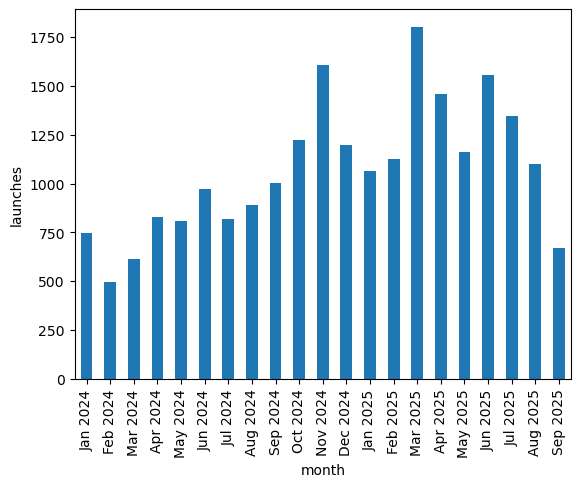

In [19]:
monthly_counts=df['month'].value_counts().sort_index()
monthly_counts.index = monthly_counts.index.strftime('%b %Y')
ax=monthly_counts.plot(kind='bar')
plt.ylabel('launches')

**Let's label the data!**

In [20]:
df['label']=np.where(df['most_recent_review']>10, 1, 0) 
df['label'].mean()

0.12118787232150796

# 3. EDA

**What's the success vs failure distribution per month?**

In [45]:
! pip install -q seaborn 

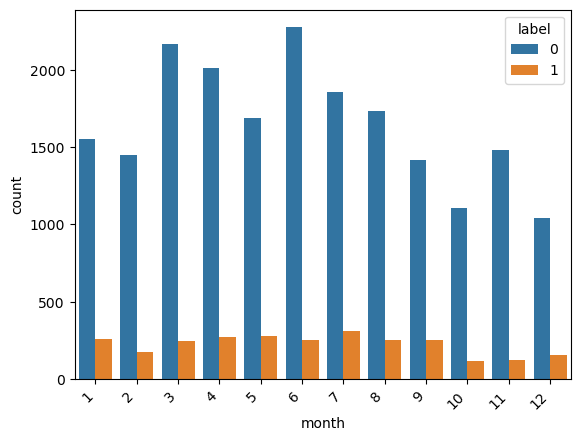

In [43]:
import seaborn as sns
sns.countplot(data=df,x='month',hue='label',order=sorted(df['month'].unique()))
plt.xticks(rotation=45,ha='right') ;




**What's the success rate per month?**

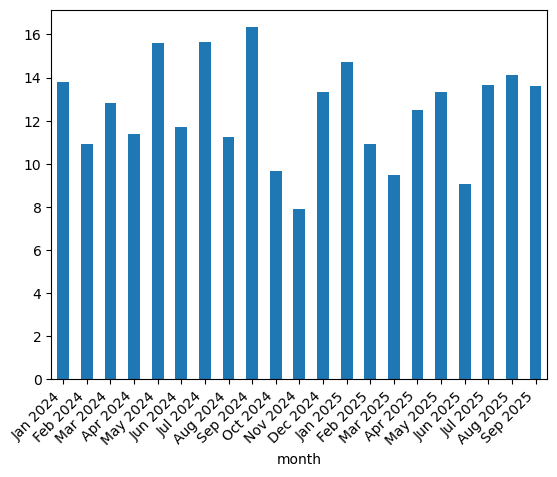

In [23]:
success_rate=df.groupby('month')['label'].mean()*100
success_rate.index=success_rate.index.strftime("%b %Y")
success_rate.plot(kind='bar')
plt.xticks(rotation=45, ha='right') ;


**What is the success rate per category?**

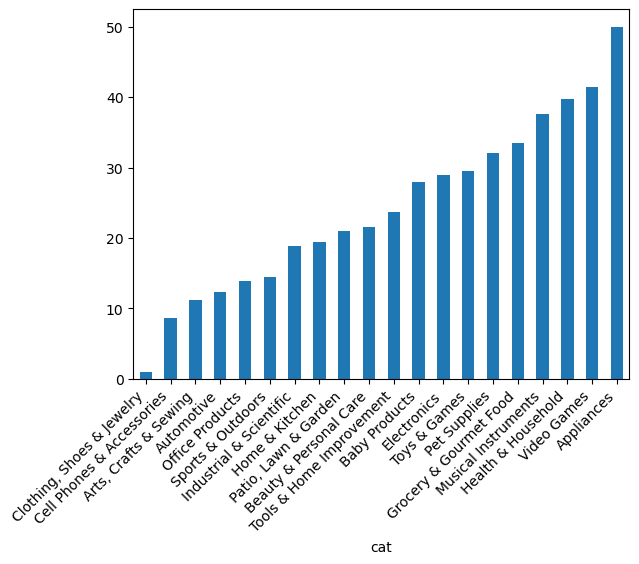

In [24]:
success_rate=df.groupby('cat')['label'].mean()*100

success_rate.sort_values().plot(kind='bar')
plt.xticks(rotation=45, ha='right') ;


# 4. Feature Engineering

**Data splitting. From the data we have we found that September 2025 is the last month that we can reliably collect review data for. We did a 80/20 split based on time, where before 2025-06-01, we used as training data and after 2025-06-01, we used as test data.**

**Fatures we will be using:**

- Product positiong: pricing, cat,material,description, brand_store_name 
- Brand: brank_name, seller
- listing: description, title

**feature engineering steps:

Dealing with missing value:

Upon chekcing we noticed material,description, brand_store_name are missing more than 40% of the data, we decided to drop all three columns.

1 seller is missing and we dropped the row.

cat filled with unknown and price filled with median.

Column transformation:

Numeric value:

we first devided months (e.g. 2025-03-01) to month and year (two numeric columns). 

catogorical columns are encoded with one hot encoder.

Title we first went to tidif combine with Light Gradient Boosting Machine LGBM, which is much faster than XGBoost. this is chosen over regression model becaue the mixed data type and over randomforest because of the speed


We got a f1 score of 0.2 which is not ideal. Future work is to try embedding to improve the score.

In [76]:
# not include asin as it is identifier
df=df_new[has_review_6_month]
df['seller']=df['buybox'].map(lambda x: (json.loads(x).get('buyBoxSellerIdHistory') or [None])[-1])


In [77]:
df['label']=np.where(df['most_recent_review']>10, 1, 0) 
df=df[['month','title','cat','price','seller','description','material','brand_store_name','label']]
df['month']=pd.to_datetime(df['month'])
df.isnull().sum()

month                   0
title                   0
cat                   965
price                1162
seller                  1
description         13309
material             8028
brand_store_name     8651
label                   0
dtype: int64

In [78]:
#drop seller na row
df.dropna(subset=['seller'],inplace=True)
# drop description,material,brand_store_name column
df.drop(['description','material','brand_store_name'],axis=1,inplace=True)
df['date']=df['month']
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month


In [161]:
train_raw=df[df['date']<'2025-06-01'] 
test_raw=df[df['date']>='2025-06-1']
train_raw.shape[0]/df.shape[0]

0.7924243097852666

In [164]:
feature=df.columns.tolist()
target='label'
feature.remove(target)

X_train=train_raw[feature]
y_train=train_raw[target]

X_test=test_raw[feature]
y_test=test_raw[target]


In [165]:
df.dtypes

month        int32
title          str
cat            str
price      float64
seller         str
            ...   
emb_379    float32
emb_380    float32
emb_381    float32
emb_382    float32
emb_383    float32
Length: 392, dtype: object

In [166]:
X_train.shape

(17824, 391)

# 5. Modeling

## 5.1 LGBM+Tfidf

In [167]:
! pip install lightgbm

In [168]:
from sklearn.base import TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from lightgbm import LGBMClassifier

    
cat_transformer=Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='unknow')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])
preprocessing=ColumnTransformer([
    ('numeric_imp',SimpleImputer(strategy='median'),['price','month','year']), # can't use custom class because it takes X as df, here it takes array
    ('cat',cat_transformer,['cat','seller']),
    ('tfidf',TfidfVectorizer(max_features=200,stop_words='english'),'title') # title needs to be 1d array
]
)

pipe=Pipeline([
    ('tf',preprocessing),
    ('boosting',LGBMClassifier(class_weight='balanced'))
])

model=pipe.fit(X_train,y_train)
        



[LightGBM] [Info] Number of positive: 2155, number of negative: 15669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27944
[LightGBM] [Info] Number of data points in the train set: 17824, number of used features: 304
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


              precision    recall  f1-score   support

           0       0.95      0.77      0.85      4098
           1       0.30      0.70      0.42       571

    accuracy                           0.76      4669
   macro avg       0.62      0.74      0.64      4669
weighted avg       0.87      0.76      0.80      4669

ROC-AUC:   0.8346419038290431
PR-AUC:    0.3296542840127456


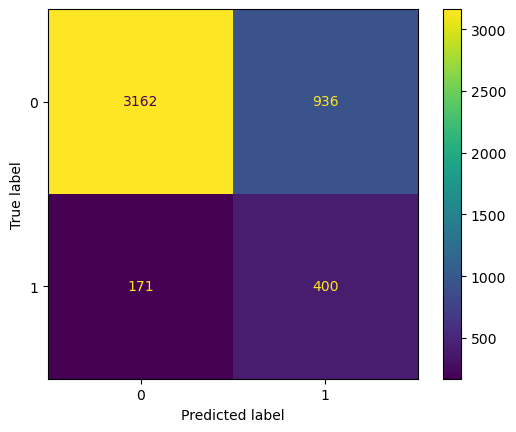

In [172]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, ConfusionMatrixDisplay
)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred=(y_prob>0.6).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_prob))
print("PR-AUC:   ", average_precision_score(y_test, y_prob))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


**the gap between high ROC-AUC and low F1 is telling me:

"My model learned something about success, but not enough to be confident about any individual prediction"**

ROC-AUC of 0.83 suggests the model captures real signal in product positioning. The gap with F1 reflects an irreducible uncertainty in launch outcomes — products that look identical at launch diverge based on post-launch execution factors not observable in the data. This aligns with findings in the product success prediction literature."

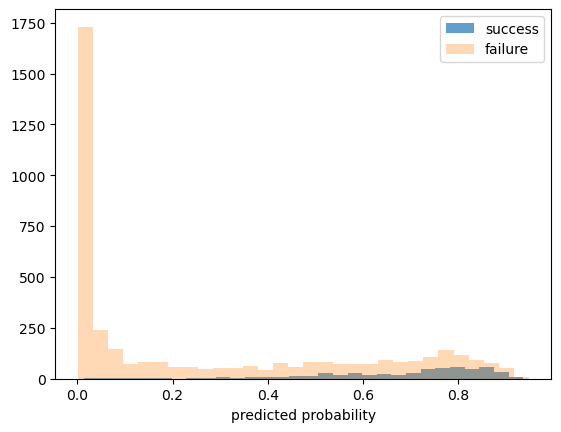

In [173]:
import matplotlib.pyplot as plt

plt.hist(y_prob[y_test==1], bins=30, alpha=0.7, label='success')
plt.hist(y_prob[y_test==0], bins=30, alpha=0.3, label='failure')
plt.legend()
plt.xlabel('predicted probability')
plt.show()


Failure and Success are not well seperated at threshold 0.3. This means the model sees features in those failures that look like success features — it can't distinguish them. e.g. A failure with a good title, reasonable price, and popular category looks identical to a success at launch time.

## 5.2 LGBM + embedding

**Try embedding to capture the meaning behind the titiles. I used google colab to do the embedding since my computer does not have enough compute power**

In [174]:
df['title'].to_csv('titles.csv',index=False)

In [197]:
    
cat_transformer=Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='unknow')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])


preprocessing=ColumnTransformer([
    ('numeric_imp',SimpleImputer(strategy='median'),['price','month','year']+em_cols), # can't use custom class because it takes X as df, here it takes array
    ('cat',cat_transformer,['cat','seller']),
]
)

pipe=Pipeline([
    ('tf',preprocessing),
    ('boosting',LGBMClassifier(class_weight='balanced'))
])

model=pipe.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 2155, number of negative: 15669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98389
[LightGBM] [Info] Number of data points in the train set: 17824, number of used features: 488
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [198]:
y_predict_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_predict_prob>0.6).astype(int)
y_pred

array([1, 1, 0, ..., 0, 0, 0])

In [199]:
print(classification_report(y_test,y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test,y_prob)}")
print("PR-AUC:   ", average_precision_score(y_test, y_prob))



              precision    recall  f1-score   support

           0       0.94      0.85      0.89      4098
           1       0.36      0.61      0.46       571

    accuracy                           0.82      4669
   macro avg       0.65      0.73      0.67      4669
weighted avg       0.87      0.82      0.84      4669

ROC_AUC: 0.8469735354224306
PR-AUC:    0.35266999047274633


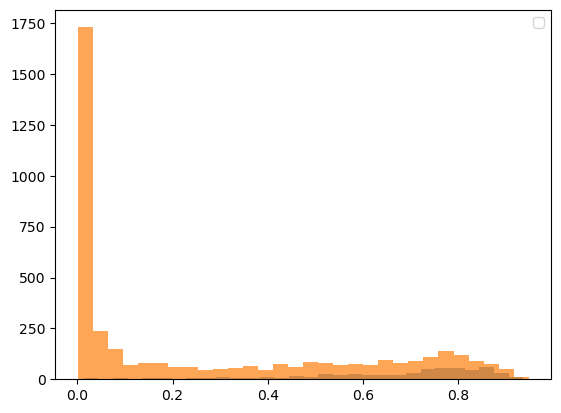

In [186]:
plt.hist(y_prob[y_test==1],alpha=0.7,bins=30)
plt.hist(y_prob[y_test==0],alpha=0.7,bins=30)
plt.legend()


## 5.3 xgboost + embedding

In [200]:
from xgboost import XGBClassifier
cat_transformer=Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='unknow')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])


preprocessing=ColumnTransformer([
    ('numeric_imp',SimpleImputer(strategy='median'),['price','month','year']+em_cols), # can't use custom class because it takes X as df, here it takes array
    ('cat',cat_transformer,['cat','seller']),
]
)

pipe=Pipeline([
    ('tf',preprocessing),
    ('boosting',XGBClassifier(class_weight='balanced'))
])

model=pipe.fit(X_train,y_train)


[14:50:41] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.



In [205]:
y_predict_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_predict_prob>0.1).astype(int)
print(classification_report(y_test,y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test,y_prob)}")
print("PR-AUC:   ", average_precision_score(y_test, y_prob))



              precision    recall  f1-score   support

           0       0.95      0.80      0.87      4098
           1       0.34      0.71      0.46       571

    accuracy                           0.79      4669
   macro avg       0.64      0.76      0.66      4669
weighted avg       0.88      0.79      0.82      4669

ROC_AUC: 0.8469735354224306
PR-AUC:    0.35266999047274633


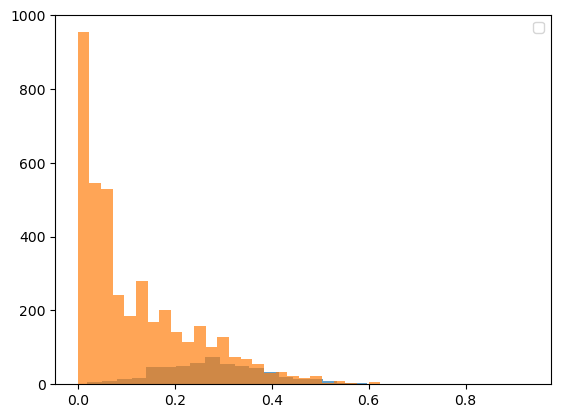

In [206]:
plt.hist(y_prob[y_test==1],alpha=0.7,bins=30)
plt.hist(y_prob[y_test==0],alpha=0.7,bins=30)
plt.legend()

## 5.4 xgboost + tfidf

In [187]:
from sklearn.ensemble import RandomForestClassifier

cat_transformer=Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='unknow')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])
preprocessing=ColumnTransformer([
    ('numeric_imp',SimpleImputer(strategy='median'),['price','month','year']), # can't use custom class because it takes X as df, here it takes array
    ('cat',cat_transformer,['cat','seller']),
    ('tfidf',TfidfVectorizer(max_features=200,stop_words='english'),'title') # title needs to be 1d array
]
)
pipe=Pipeline([
    ('tf',preprocessing),
    ('rf',RandomForestClassifier(class_weight='balanced'))
])

model=pipe.fit(X_train,y_train)


In [190]:
y_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_prob>0.2).astype(int)
print(classification_report(y_test,y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test,y_prob)}")

              precision    recall  f1-score   support

           0       0.97      0.73      0.83      4098
           1       0.30      0.82      0.43       571

    accuracy                           0.74      4669
   macro avg       0.63      0.77      0.63      4669
weighted avg       0.88      0.74      0.78      4669

ROC_AUC: 0.8435869361757776


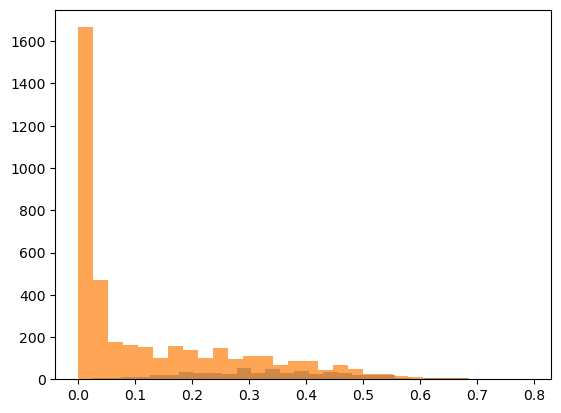

In [191]:
plt.hist(y_prob[y_test==1],alpha=0.7,bins=30)
plt.hist(y_prob[y_test==0],alpha=0.7,bins=30) ;

## 5.5 Random Forest + embedding

In [214]:
cat_transformer=Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='unknow')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])


preprocessing=ColumnTransformer([
    ('numeric_imp',SimpleImputer(strategy='median'),['price','month','year']+em_cols), # can't use custom class because it takes X as df, here it takes array
    ('cat',cat_transformer,['cat','seller']),
]
)

pipe=Pipeline([
    ('tf',preprocessing),
    ('boosting',RandomForestClassifier(class_weight='balanced'))
])

model=pipe.fit(X_train,y_train)

In [193]:
y_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_prob>0.2).astype(int)
print(classification_report(y_test,y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test,y_prob)}")

              precision    recall  f1-score   support

           0       0.96      0.78      0.86      4098
           1       0.32      0.75      0.45       571

    accuracy                           0.78      4669
   macro avg       0.64      0.76      0.65      4669
weighted avg       0.88      0.78      0.81      4669

ROC_AUC: 0.8469735354224306


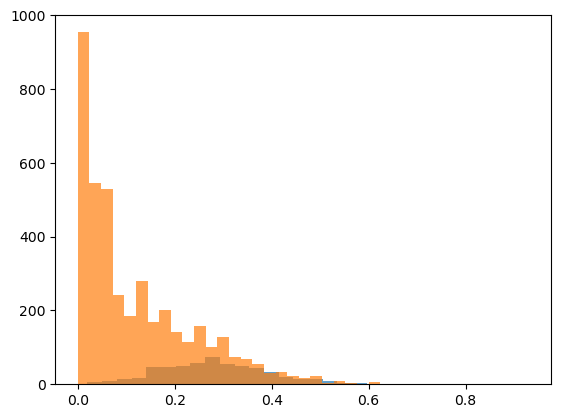

In [194]:
plt.hist(y_prob[y_test==1],alpha=0.7,bins=30)
plt.hist(y_prob[y_test==0],alpha=0.7,bins=30) ;

<BarContainer object of 3 artists>

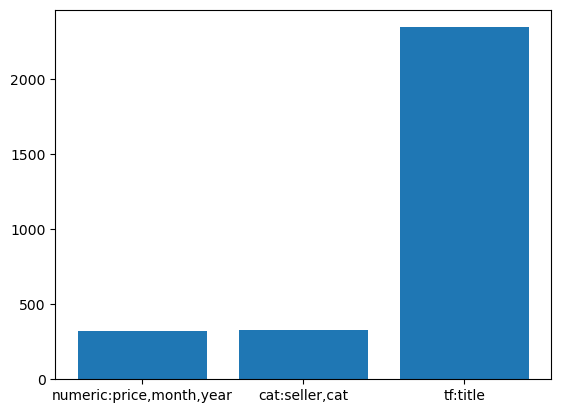

In [36]:
importances=model.steps[1][1].feature_importances_
features=model.steps[0][1].get_feature_names_out()
feature_imp=pd.DataFrame({'import':importances},index=features)

numeric=feature_imp[feature_imp.index.str.startswith('numeric')]['import'].sum()
cat=feature_imp[feature_imp.index.str.startswith('cat')]['import'].sum()
tfidf=feature_imp[feature_imp.index.str.startswith('tfidf')]['import'].sum()

x=['numeric:price,month,year','cat:seller,cat','tf:title']
height=[numeric,cat,tfidf]
plt.bar(x=x,height=height)
